In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = "C:/Users/tamer/Documents/PhD/ML/Markers/markers.xlsx"
df = pd.read_excel(data, sheet_name='Sheet8')

ValueError: Worksheet named 'Sheet8' not found

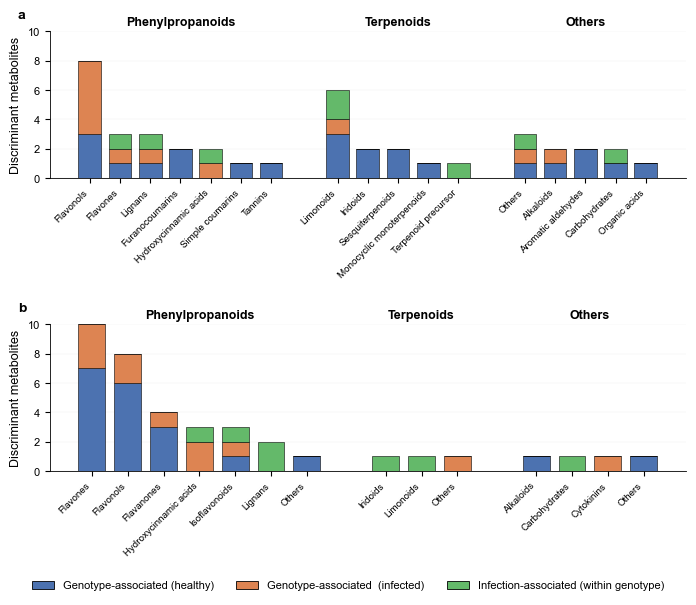

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# GLOBAL JOURNAL STYLE (Double column optimized)
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42
})

# ==================================================
# PARAMETERS
# ==================================================
data_path = "C:/Users/tamer/Documents/PhD/ML/Markers/markers.xlsx"

palette = {
    "Constitutif": "#4C72B0",
    "I-1": "#DD8452",
    "I-2": "#64B96A"
}

super_order = [
    "Phenylpropanoids",
    "Terpenoids",
    "Others"
]

# ==================================================
# FUNCTION TO BUILD ONE PANEL
# ==================================================
def build_panel(df, ax, panel_letter):

    df = df[df["Metabolite_family"].notna()].copy()

    if "count" not in df.columns:
        df["count"] = df["Constitutif"] + df["I-1"] + df["I-2"]

    df["Class 2"] = pd.Categorical(
        df["Class 2"],
        categories=super_order,
        ordered=True
    )

    df = df.sort_values(
        ["Class 2", "count", "Metabolite_family"],
        ascending=[True, False, True]
    )

    x_positions = []
    current_x = 0
    last_super = None

    for _, row in df.iterrows():
        if row["Class 2"] != last_super:
            current_x += 1.2
        x_positions.append(current_x)
        current_x += 1
        last_super = row["Class 2"]

    df["xpos"] = x_positions

    width = 0.75

    # Bars
    ax.bar(df["xpos"], df["Constitutif"],
           width=width,
           color=palette["Constitutif"],
           edgecolor="black",
           linewidth=0.4)

    ax.bar(df["xpos"], df["I-1"],
           width=width,
           bottom=df["Constitutif"],
           color=palette["I-1"],
           edgecolor="black",
           linewidth=0.4)

    ax.bar(df["xpos"], df["I-2"],
           width=width,
           bottom=df["Constitutif"] + df["I-1"],
           color=palette["I-2"],
           edgecolor="black",
           linewidth=0.4)

    # Axes
    ax.set_xticks(df["xpos"])
    ax.set_xticklabels(df["Metabolite_family"],
                       rotation=45,
                       ha="right")

    ax.grid(axis="y", linewidth=0.3, color="#EDEDED")
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Panel letter
    ax.text(-0.05, 1.15,
            panel_letter,
            transform=ax.transAxes,
            fontsize=10,
            fontweight="bold",
            va="top",
            ha="left")

    # Superclass labels
    for superclass in df["Class 2"].cat.categories:

        subset = df[df["Class 2"] == superclass]
        if len(subset) == 0:
            continue

        center = subset["xpos"].mean()

        ax.text(center,
                10.2,
                superclass,
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold")

    return df


# ==================================================
# LOAD DATA
# ==================================================
df_lemon = pd.read_excel(data_path, sheet_name="Lemon")
df_orange = pd.read_excel(data_path, sheet_name="Orange")

# ==================================================
# CREATE FIGURE (DOUBLE COLUMN SIZE)
# ==================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(7, 6.2),   # <-- DOUBLE COLUMN WIDTH
    sharey=True
)

df_lemon = build_panel(df_lemon, axes[0], "a")
df_orange = build_panel(df_orange, axes[1], "b")

# Y label
axes[0].set_ylabel("Discriminant metabolites")
axes[1].set_ylabel("Discriminant metabolites")

# Common Y scale
axes[0].set_ylim(0, 10)
axes[0].set_yticks(np.arange(0, 11, 2))

# Legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=palette["Constitutif"], ec="black", linewidth=0.6),
    plt.Rectangle((0, 0), 1, 1, color=palette["I-1"], ec="black", linewidth=0.6),
    plt.Rectangle((0, 0), 1, 1, color=palette["I-2"], ec="black", linewidth=0.6)
]

labels = [
    "Genotype-associated (healthy)",
    "Genotype-associated  (infected)",
    "Infection-associated (within genotype)"
]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# EXPORT
plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/Markers/Lemon_Orange_DM_distribution.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/Markers/Lemon_Orange_DM_distribution.tiff",
    dpi=600,
    bbox_inches="tight",
    format="tiff"
)

plt.show()